<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/hmm-vae/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
data = pd.read_csv(
    "/content/drive/MyDrive/data_dipl_proj/100_Portfolios_10x10_Daily_valueweighted.csv",
    parse_dates=True,
    low_memory=False
)
data = data.set_index("Date")
data.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
19260701,-99.99,0.00,-99.99,1.59,-3.08,4.64,2.57,3.81,-0.52,-0.84,...,0.00,1.10,-0.15,-0.03,0.52,0.48,-0.43,-0.08,0.17,-99.99
19260702,-99.99,-0.27,-99.99,0.00,-0.97,-4.10,0.31,-0.47,2.74,-0.27,...,0.31,0.71,0.97,0.57,0.52,0.15,0.63,-0.04,0.34,-99.99
19260706,-99.99,1.01,-99.99,-4.69,2.35,-1.79,0.00,2.44,-5.18,-0.23,...,0.49,-0.19,0.89,0.31,-0.12,-0.18,-0.33,-0.40,-0.34,-99.99
19260707,-99.99,-1.67,-99.99,4.92,0.51,5.27,0.00,-0.74,-0.24,-0.02,...,-0.20,-0.01,0.66,0.38,0.03,0.25,-0.29,0.52,0.17,-99.99
19260708,-99.99,0.00,-99.99,1.56,-0.51,-1.06,0.00,4.90,0.45,0.26,...,0.56,-0.12,0.35,0.55,-0.14,0.19,-0.12,0.54,0.51,-99.99


In [24]:
data = data.replace(r'^\s*$', np.nan, regex=True)

data = data.replace({
    '-99.99': np.nan,
    '-999': np.nan,
    '-999.0': np.nan,
    '-999.00': np.nan,
    -99.99: np.nan,
    -999: np.nan,
    -999.0: np.nan,
    -100: np.nan,
    -100.0: np.nan,
    -100.00: np.nan
})

data = data.apply(lambda col: pd.to_numeric(col, errors='coerce'))
data = data / 100
#data = data.clip(lower=-0.9999)
#data = np.log1p(data)
data = data.fillna(0.0)
data = data.astype(np.float32)
data.index = pd.to_datetime(data.index, format="%Y%m%d")

In [25]:
zeros_by_year = (data == 0).groupby(data.index.year).sum().sum(axis=1)
print(zeros_by_year[:25])


Date
1926    1570
1927    2668
1928    2170
1929    2201
1930    3421
1931    4552
1932    5131
1933    3029
1934    1942
1935    1923
1936    1842
1937    1342
1938    1379
1939    1962
1940    1941
1941    1994
1942    2472
1943    1634
1944    1093
1945     521
1946     164
1947     226
1948     390
1949     520
1950     523
dtype: int64


In [26]:
data = data[data.index > "1945-01-01"]
data

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
1945-01-02,0.0013,0.0506,-0.0094,0.0000,-0.0042,0.0344,0.0003,0.0093,0.0082,0.0038,...,0.0011,-0.0028,-0.0001,0.0049,0.0084,0.0114,0.0034,0.0135,0.0067,-0.0031
1945-01-03,0.0301,0.0072,0.0286,0.0150,0.0355,0.0109,0.0211,0.0101,-0.0041,0.0049,...,0.0086,0.0107,0.0033,0.0079,0.0054,0.0134,0.0150,0.0176,0.0200,0.0084
1945-01-04,0.0159,-0.0087,-0.0093,0.0375,0.0175,-0.0092,0.0000,0.0193,0.0085,0.0025,...,0.0004,0.0010,0.0021,0.0048,0.0066,0.0041,0.0036,0.0132,0.0098,0.0013
1945-01-05,-0.0132,0.0233,-0.0093,0.0000,-0.0050,0.0303,0.0012,0.0001,0.0082,0.0026,...,-0.0031,-0.0026,-0.0014,0.0019,-0.0025,0.0137,0.0017,0.0099,-0.0050,-0.0046
1945-01-06,-0.0192,-0.0193,-0.0094,0.0000,0.0100,-0.0223,-0.0091,0.0005,-0.0166,0.0018,...,-0.0004,-0.0023,0.0020,-0.0047,0.0043,-0.0048,-0.0023,-0.0018,0.0009,0.0028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,0.0025,-0.0382,-0.0040,-0.0153,-0.0195,0.0111,0.0075,0.0055,-0.0011,-0.0052,...,0.0174,0.0168,0.0046,0.0114,0.0051,0.0090,-0.0011,-0.0016,0.0100,0.0226
2025-10-28,-0.0092,-0.0089,-0.0060,-0.0048,-0.0070,-0.0117,-0.0003,-0.0028,-0.0056,-0.0038,...,0.0138,-0.0029,-0.0045,-0.0131,0.0076,-0.0023,-0.0074,-0.0032,-0.0067,0.0196
2025-10-29,-0.0199,-0.0251,-0.0167,-0.0223,-0.0080,-0.0096,-0.0231,-0.0232,-0.0197,-0.0147,...,0.0050,0.0079,-0.0214,-0.0074,-0.0071,0.0036,-0.0087,-0.0074,-0.0095,-0.0149


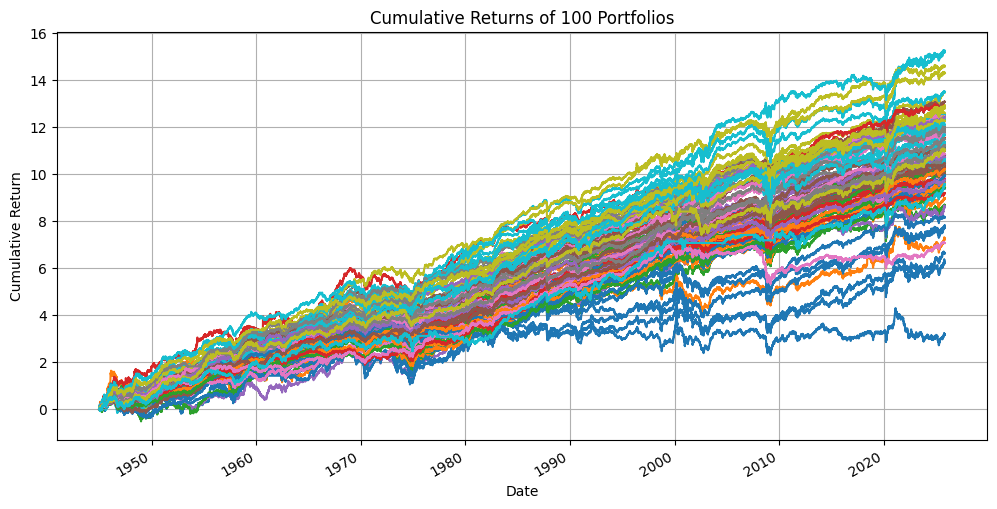

In [27]:
cum_returns = data.cumsum()
cum_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns of 100 Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid()
plt.legend().set_visible(False)
plt.show()

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, StudentT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = F.leaky_relu(self.fc1(x))
        h = F.leaky_relu(self.fc2(h))
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar


In [30]:
class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super().__init__()
    self.fc1 = nn.Linear(latent_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, hidden_dim)
    self.fc_out = nn.Linear(hidden_dim, output_dim)

  def forward(self, z):
    h = F.leaky_relu(self.fc1(z))
    h = F.leaky_relu(self.fc2(h))
    out = self.fc_out(h)
    return out


In [31]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar


In [32]:
def vae_loss(x_recon, x, mu, logvar, kl_weight=1):
  recon_loss = F.mse_loss(x_recon, x, reduction='sum')
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return recon_loss + kl_weight * kl_loss


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

data_train, data_test = train_test_split(
    data, test_size=0.15, random_state=1000, shuffle=False
)

scaler = MinMaxScaler()
data_train = scaler.fit_transform(data_train)
data_test = scaler.transform(data_test)

In [35]:
X_train_tensor = torch.tensor(data_train, dtype=torch.float32)
X_test_tensor = torch.tensor(data_test, dtype=torch.float32)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor)

batch_size = 128

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [38]:
def train(model, epochs, device, train_loader, kl_anneal_cycles=4, ratio_increase=0.5):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

    total_steps = epochs * len(train_loader)

    steps_per_cycle = total_steps // kl_anneal_cycles

    steps_to_increase = int(steps_per_cycle * ratio_increase)

    global_step = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch_idx, (data,) in enumerate(train_loader):
            data = data.to(device)

            step_in_cycle = global_step % steps_per_cycle

            if step_in_cycle < steps_to_increase:
                kl_weight = step_in_cycle / steps_to_increase
            else:
                kl_weight = 1.0

            optimizer.zero_grad()

            recon_batch, mu, logvar = model(data)

            loss = vae_loss(recon_batch, data, mu, logvar, kl_weight=kl_weight)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            global_step += 1

        avg_train_loss = train_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} | Average Train Loss: {avg_train_loss:.4f} | Final Cycle KL Weight: {kl_weight:.2f}")

    return model


In [39]:
vae = VAE(input_dim=100, hidden_dim=64, latent_dim=10)
vae = train(vae, epochs=400, device=device, train_loader=train_loader)

Epoch 1/400 | Average Train Loss: 7.3432 | Final Cycle KL Weight: 0.02
Epoch 2/400 | Average Train Loss: 0.5287 | Final Cycle KL Weight: 0.04
Epoch 3/400 | Average Train Loss: 0.5209 | Final Cycle KL Weight: 0.06
Epoch 4/400 | Average Train Loss: 0.5009 | Final Cycle KL Weight: 0.08
Epoch 5/400 | Average Train Loss: 0.4854 | Final Cycle KL Weight: 0.10
Epoch 6/400 | Average Train Loss: 0.4748 | Final Cycle KL Weight: 0.12
Epoch 7/400 | Average Train Loss: 0.4717 | Final Cycle KL Weight: 0.14
Epoch 8/400 | Average Train Loss: 0.4564 | Final Cycle KL Weight: 0.16
Epoch 9/400 | Average Train Loss: 0.3721 | Final Cycle KL Weight: 0.18
Epoch 10/400 | Average Train Loss: 0.2590 | Final Cycle KL Weight: 0.20
Epoch 11/400 | Average Train Loss: 0.2373 | Final Cycle KL Weight: 0.22
Epoch 12/400 | Average Train Loss: 0.2261 | Final Cycle KL Weight: 0.24
Epoch 13/400 | Average Train Loss: 0.2198 | Final Cycle KL Weight: 0.26
Epoch 14/400 | Average Train Loss: 0.2154 | Final Cycle KL Weight: 0.28
E

In [ ]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
# https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/
# https://huggingface.co/blog/NormalUhr/kl-divergence-estimator-rl-llm
# http://joschu.net/blog/kl-approx.html